## Configurable MAE comparison plotter

Edit `RUN_MODELS` in the following cell. Each entry is `(run, base or full or transfer, label)`.

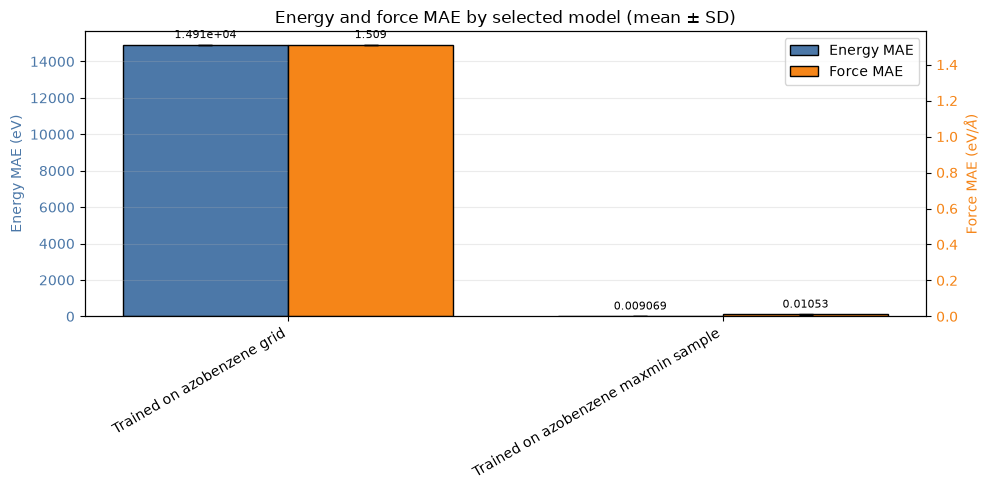

In [2]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# Edit this list: (run number or 'run_N', 'base', 'full', or 'transfer', plotted label).
RUN_MODELS = [
    ('run_3', 'base', 'Trained on azobenzene grid'),
    ('run_4', 'base', 'Trained on azobenzene maxmin sample'),
]

MODEL_KEYS = {
    'base': 'base_models',
    'full': 'full_high_fidelity_models',
    'transfer': 'transfer_models',
}

# This works whether the notebook is run from the repository root or notebooks/.
output_root = next(
    (path for path in (Path('scripts/output'), Path('../scripts/output')) if path.is_dir()),
    None,
)
if output_root is None:
    raise FileNotFoundError('Run outputs could not be found.')

records = []
for run, model_type, label in RUN_MODELS:
    run_name = f'run_{run}' if isinstance(run, int) else str(run)
    if not run_name.startswith('run_'):
        run_name = f'run_{run_name}'
    model_type = model_type.lower()
    if model_type not in MODEL_KEYS:
        raise ValueError(f"{run_name}: model type must be 'base', 'full', or 'transfer', not {model_type!r}.")

    result_path = output_root / run_name / 'result.json'
    if not result_path.is_file():
        raise FileNotFoundError(f'Missing result file: {result_path}')
    metrics_by_model = json.loads(result_path.read_text()).get('metrics', {})
    model_key = MODEL_KEYS[model_type]
    if model_key not in metrics_by_model:
        available = ', '.join(metrics_by_model) or 'none'
        raise KeyError(f"{run_name} has no {model_type!r} metrics; available: {available}.")

    metrics = metrics_by_model[model_key]
    records.append({
        'label': label,
        'energy_mean': metrics['energy_mae_ev']['mean'],
        'energy_std': np.sqrt(metrics['energy_mae_ev']['variance']),
        'force_mean': metrics['force_mae_ev_per_ang']['mean'],
        'force_std': np.sqrt(metrics['force_mae_ev_per_ang']['variance']),
    })

labels = [record['label'] for record in records]
energy_means = [record['energy_mean'] for record in records]
energy_stds = [record['energy_std'] for record in records]
force_means = [record['force_mean'] for record in records]
force_stds = [record['force_std'] for record in records]
x = np.arange(len(records))
width = 0.38

fig, energy_ax = plt.subplots(figsize=(max(10, 1.8 * len(records)), 5))
force_ax = energy_ax.twinx()
energy_bars = energy_ax.bar(
    x - width / 2, energy_means, width, yerr=energy_stds, capsize=5,
    color='#4C78A8', edgecolor='black', label='Energy MAE',
)
force_bars = force_ax.bar(
    x + width / 2, force_means, width, yerr=force_stds, capsize=5,
    color='#F58518', edgecolor='black', label='Force MAE',
)
energy_ax.bar_label(energy_bars, labels=[f'{mean:.4g}' for mean in energy_means], padding=3, fontsize=8)
force_ax.bar_label(force_bars, labels=[f'{mean:.4g}' for mean in force_means], padding=3, fontsize=8)
energy_ax.set_xticks(x, labels, rotation=30, ha='right')
energy_ax.set_title('Energy and force MAE by selected model (mean ± SD)')
energy_ax.set_ylabel('Energy MAE (eV)', color='#4C78A8')
force_ax.set_ylabel(r'Force MAE (eV/$\AA$)', color='#F58518')
energy_ax.tick_params(axis='y', labelcolor='#4C78A8')
force_ax.tick_params(axis='y', labelcolor='#F58518')
energy_ax.grid(axis='y', alpha=0.25)
energy_ax.legend(handles=[energy_bars, force_bars], loc='upper right')
fig.tight_layout()
plt.show()
